**RAVDESS / TESS**

**Step 1: Install required audio processing libraries**

In [1]:
!pip install librosa soundfile scikit-learn tensorflow matplotlib seaborn

import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


**Step 2: Download RAVDESS Dataset directly from Kaggle/Web**

In [2]:
import os
import urllib.request
import zipfile

# Dataset directory setup
os.makedirs('ravdess_data', exist_ok=True)

# RAVDESS Dataset direct zip link from standard mirror
dataset_url = "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip"
zip_path = "ravdess_speech.zip"

print("Downloading RAVDESS Audio Dataset...")
urllib.request.urlretrieve(dataset_url, zip_path)

print("Extracting Audio Files...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('ravdess_data')

print("Extraction Complete! Audio files ready.")

Extracting Audio Files...
Extraction Complete! Audio files ready.


**Step 3: Extract MFCC Features using Librosa**

In [3]:
emotions_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

def extract_mfcc(file_path):
    # Audio load karein (22050 Hz sampling rate par)
    audio, sr = librosa.load(file_path, duration=3, offset=0.5)
    # 40 MFCC features extract karein
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    # Time axis par mean lein taaki 1D vector ban jaye
    mfccs_processed = np.mean(mfccs.T, axis=0)
    return mfccs_processed

features = []
labels = []

# Directory traverse karke audio process karein
print("Extracting MFCCs from audio files...")
for root, dirs, files in os.walk('ravdess_data'):
    for file in files:
        if file.endswith('.wav'):
            file_path = os.path.join(root, file)
            # Filename parsing for emotion code
            parts = file.split('-')
            if len(parts) >= 3:
                emotion_code = parts[2]
                if emotion_code in emotions_map:
                    mfcc_feat = extract_mfcc(file_path)
                    features.append(mfcc_feat)
                    labels.append(emotions_map[emotion_code])

X = np.array(features)
y = np.array(labels)

print(f"Features extracted successfully! X shape: {X.shape}, y shape: {y.shape}")

Extracting MFCCs from audio files...
Features extracted successfully! X shape: (1440, 40), y shape: (1440,)


**Step 4: Data Preprocessing & 1D-CNN Model Training**

In [4]:
from tensorflow.keras.utils import to_categorical

# Label Encoding (e.g., 'happy' -> 0, 'sad' -> 1)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

In [6]:
# Reshape for 1D-CNN: (samples, time_steps, channels) -> (N, 40, 1)
X_train_cnn = np.expand_dims(X_train, -1)
X_test_cnn = np.expand_dims(X_test, -1)

# Build 1D-CNN Architecture
model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(40, 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y_categorical.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Training 1D-CNN Model...")
history = model.fit(
    X_train_cnn, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_cnn, y_test),
    verbose=1
)

Training 1D-CNN Model...
Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.1519 - loss: 5.5038 - val_accuracy: 0.2083 - val_loss: 2.0253
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1840 - loss: 2.1881 - val_accuracy: 0.1667 - val_loss: 2.0314
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1944 - loss: 2.0549 - val_accuracy: 0.2257 - val_loss: 1.9676
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1727 - loss: 2.0190 - val_accuracy: 0.2222 - val_loss: 1.9732
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2066 - loss: 1.9967 - val_accuracy: 0.2257 - val_loss: 1.9441
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2335 - loss: 1.9850 - val_accuracy: 0.2222 - val_loss: 1.9241
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2153 - loss: 1.9789 - val_accuracy: 0.2743 - val_loss: 1.8645
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2396 - loss: 1.9443 -

**Step 5: Model Evaluation & Confusion Matrix Plotting**

In [7]:
# Predictions
y_pred_probs = model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification Report
print("\n=== Speech Emotion Recognition Classification Report ===")
print(classification_report(y_true, y_pred, target_names=le.classes_))

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

=== Speech Emotion Recognition Classification Report ===
              precision    recall  f1-score   support

       angry       0.64      0.47      0.55        38
        calm       0.51      0.76      0.61        38
     disgust       0.40      0.61      0.48        38
     fearful       0.55      0.56      0.56        39
       happy       0.36      0.46      0.40        39
     neutral       0.25      0.05      0.09        19
         sad       0.67      0.42      0.52        38
   surprised       0.71      0.51      0.60        39

    accuracy                           0.51       288
   macro avg       0.51      0.48      0.48       288
weighted avg       0.53      0.51      0.50       288



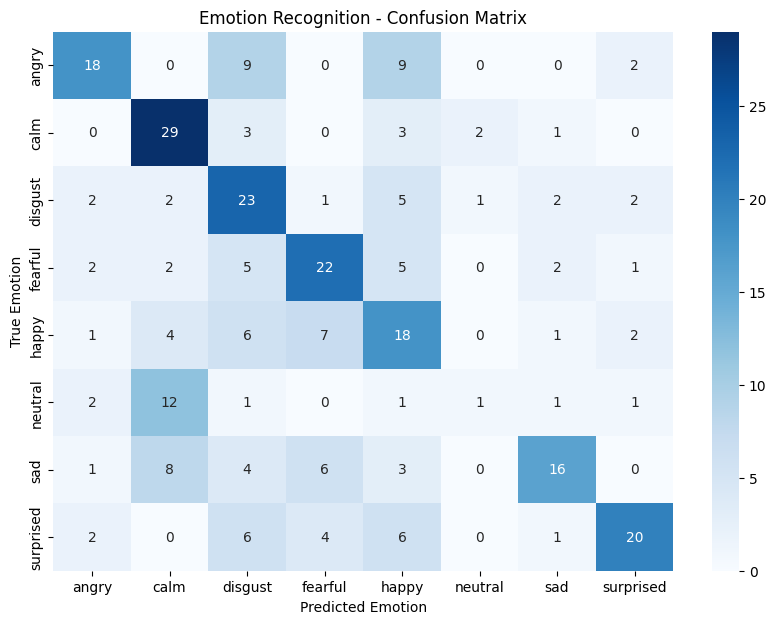

In [8]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Emotion Recognition - Confusion Matrix')
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.show()